<font color="black"><font size="7"><br>
     Projet 5 - Marketing Segmentation - EDA 
</font>
    

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, StandardScaler, QuantileTransformer, MinMaxScaler, RobustScaler
import category_encoders as ce

from sklearn.decomposition import PCA

from sklearn.impute import SimpleImputer
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis


%matplotlib inline

# Importing data

## Customers dataset

In [2]:
df_customers = pd.read_csv('data/olist_customers_dataset.csv')

In [3]:
df_customers.shape

(99441, 5)

In [4]:
df_customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


### Missing values

In [5]:
df_customers.isna().sum()

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

### EDA

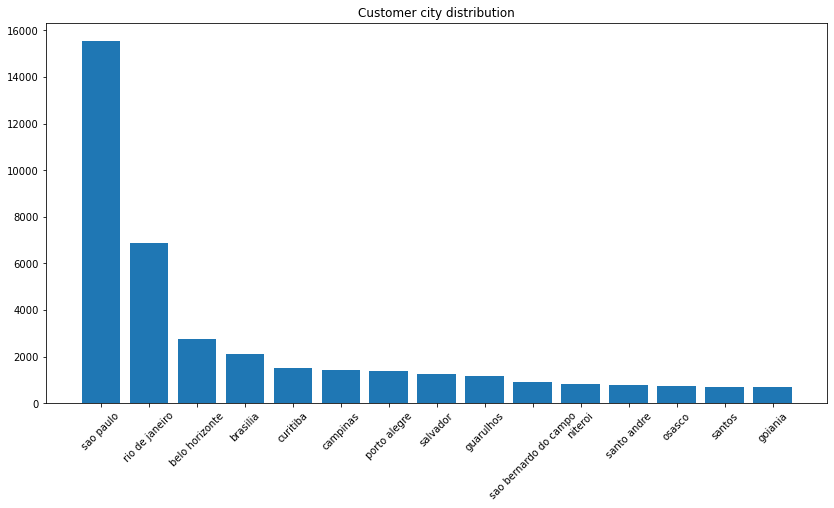

In [6]:
plt.figure(figsize=(14,7))
plt.bar(df_customers['customer_city'].value_counts().head(15).index,
        height= df_customers['customer_city'].value_counts().head(15).values)
plt.xticks(rotation=45)
plt.title('Customer city distribution')
plt.show()

## Orders dataset

In [7]:
df_orders = pd.read_csv('data/olist_orders_dataset.csv',
                        parse_dates=[3, 4, 5, 6, 7])

In [8]:
df_orders.shape

(99441, 8)

In [9]:
df_orders['order_purchase_timestamp'].describe()

<ipython-input-9-83a2d15399db>:1: FutureWarning: Treating datetime data as categorical rather than numeric in `.describe` is deprecated and will be removed in a future version of pandas. Specify `datetime_is_numeric=True` to silence this warning and adopt the future behavior now.
  df_orders['order_purchase_timestamp'].describe()


count                   99441
unique                  98875
top       2018-03-31 15:08:21
freq                        3
first     2016-09-04 21:15:19
last      2018-10-17 17:30:18
Name: order_purchase_timestamp, dtype: object

In [10]:
df_orders['customer_id'].unique().shape

(99441,)

### Missing values

In [11]:
df_orders.isna().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

### Feature engineering

get Quarters and years

In [12]:
df_orders["quarter"] = df_orders["order_purchase_timestamp"].dt.to_period('Q')

Get weekdays of purchase

In [13]:
df_orders["purchase_weekday"] = df_orders["order_purchase_timestamp"].dt.day_name()

Get period of the day of purchase

In [14]:
df_orders['purchase_period']=df_orders['order_purchase_timestamp'].dt.hour//6

Difference between etimated delivery and actual delivery

In [15]:
df_orders['delivery_difference_time']=df_orders['order_delivered_customer_date']-df_orders['order_estimated_delivery_date']

In [16]:
df_orders['delivery_difference_time'] = df_orders['delivery_difference_time'].dt.components['days']

In [17]:
df_orders['delivery_difference_time'] 

0        -8.0
1        -6.0
2       -18.0
3       -13.0
4       -10.0
         ... 
99436   -11.0
99437    -2.0
99438    -6.0
99439   -21.0
99440   -18.0
Name: delivery_difference_time, Length: 99441, dtype: float64

get recency

In [18]:
last_order = df_orders['order_purchase_timestamp'].max()

In [19]:
df_orders['recency']=last_order - df_orders['order_purchase_timestamp']

In [20]:
df_orders['recency']=df_orders['recency'].dt.total_seconds()//86400

### EDA

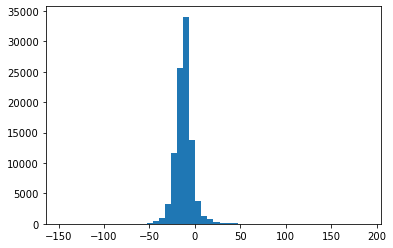

In [21]:
plt.hist(df_orders['delivery_difference_time'],bins=50)
plt.show()

In [22]:
df_orders['delivery_difference_time'].max()

188.0

In [23]:
df_orders['delivery_difference_time'].min()

-147.0

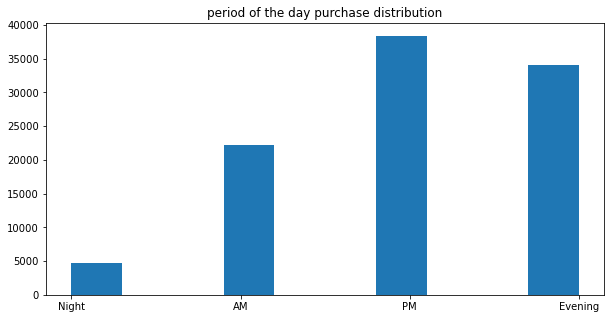

In [24]:
plt.figure(figsize=(10,5))
plt.hist(df_orders['purchase_period'])
plt.title('period of the day purchase distribution')
plt.xticks(ticks=[0,1,2,3],labels=['Night','AM','PM','Evening'])
plt.show()

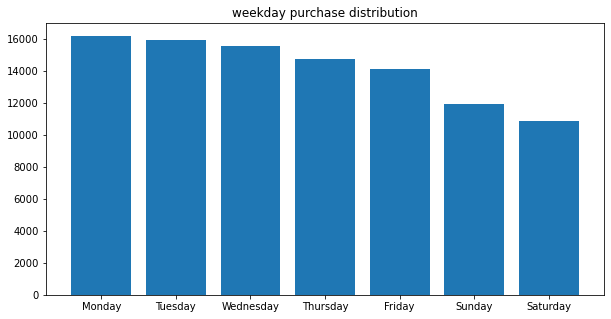

In [25]:
plt.figure(figsize=(10,5))
plt.bar(df_orders.groupby(['purchase_weekday']).count()['order_id'].sort_values(ascending=False).index,
       height=df_orders.groupby(['purchase_weekday']).count()['order_id'].sort_values(ascending=False).values)
plt.title('weekday purchase distribution')
plt.show()

In [26]:
A = df_orders.groupby(['purchase_weekday','purchase_period']).count()['order_id']

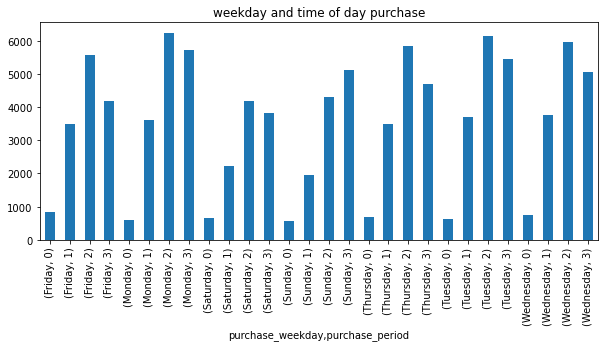

In [27]:
A.plot.bar(x='count',figsize=(10,4))
plt.title('weekday and time of day purchase')
plt.show()

In [28]:
df_orders.describe()

,purchase_period,delivery_difference_time,recency
count,99441.000000,96476.000000,99441.000000
mean,2.023934,-11.876881,289.900192
std,0.869866,10.183854,153.667316
min,0.000000,-147.000000,0.000000
25%,1.000000,-17.000000,166.000000
50%,2.000000,-12.000000,271.000000
75%,3.000000,-7.000000,400.000000
max,3.000000,188.000000,772.000000


### Joining datasets

In [29]:
master = df_customers.join(df_orders.set_index('customer_id'),on='customer_id')

In [30]:
master.shape

(99441, 17)

In [31]:
master

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,quarter,purchase_weekday,purchase_period,delivery_difference_time,recency
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,2017-05-25 10:35:35,2017-06-05,2017Q2,Tuesday,2,-11.0,519.0
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,2018-01-29 12:41:19,2018-02-06,2018Q1,Friday,3,-8.0,277.0
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,2018-06-14 17:58:51,2018-06-13,2018Q2,Saturday,2,1.0,151.0
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,2018-03-28 16:04:25,2018-04-10,2018Q1,Tuesday,2,-13.0,218.0
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,2018-08-09 20:55:48,2018-08-15,2018Q3,Sunday,1,-6.0,80.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99436,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,3937,sao paulo,SP,6760e20addcf0121e9d58f2f1ff14298,delivered,2018-04-07 15:48:17,2018-04-07 16:08:45,2018-04-11 02:08:36,2018-04-13 20:06:37,2018-04-25,2018Q2,Saturday,2,-12.0,193.0
99437,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,6764,taboao da serra,SP,9ec0c8947d973db4f4e8dcf1fbfa8f1b,delivered,2018-04-04 08:20:22,2018-04-04 08:35:12,2018-04-05 18:42:35,2018-04-11 18:54:45,2018-04-20,2018Q2,Wednesday,1,-9.0,196.0
99438,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,60115,fortaleza,CE,fed4434add09a6f332ea398efd656a5c,delivered,2018-04-08 20:11:50,2018-04-08 20:30:03,2018-04-09 17:52:17,2018-05-09 19:03:15,2018-05-02,2018Q2,Sunday,3,7.0,191.0
99439,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,92120,canoas,RS,e31ec91cea1ecf97797787471f98a8c2,delivered,2017-11-03 21:08:33,2017-11-03 21:31:20,2017-11-06 18:24:41,2017-11-16 19:58:39,2017-12-05,2017Q4,Friday,3,-19.0,347.0


## Payments dataset

In [32]:
df_payments = pd.read_csv('data/olist_order_payments_dataset.csv')

In [33]:
df_payments.shape

(103886, 5)

In [34]:
df_payments['order_id'].unique().shape

(99440,)

In [35]:
df_payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [36]:
df_payments.dtypes

order_id                 object
payment_sequential        int64
payment_type             object
payment_installments      int64
payment_value           float64
dtype: object

### Missing values

In [37]:
df_payments.isna().sum()

order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

### EDA

In [38]:
df_payments['payment_type'].value_counts()

credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: payment_type, dtype: int64

In [39]:
df_payments.describe()

,payment_sequential,payment_installments,payment_value
count,103886.000000,103886.000000,103886.000000
mean,1.092679,2.853349,154.100380
std,0.706584,2.687051,217.494064
min,1.000000,0.000000,0.000000
25%,1.000000,1.000000,56.790000
50%,1.000000,1.000000,100.000000
75%,1.000000,4.000000,171.837500
max,29.000000,24.000000,13664.080000


In [40]:
df_payments.groupby(['order_id']).sum()['payment_value'].describe()

count    99440.000000
mean       160.990267
std        221.951257
min          0.000000
25%         62.010000
50%        105.290000
75%        176.970000
max      13664.080000
Name: payment_value, dtype: float64

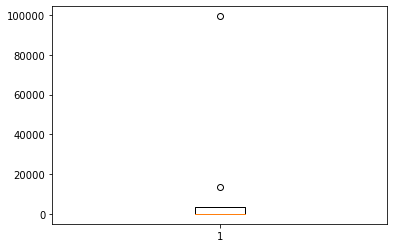

In [41]:
plt.boxplot(df_payments.groupby(['order_id']).sum()['payment_value'].describe())
plt.show()

### Feature engineering

Total payment amount

In [42]:
A=pd.DataFrame(df_payments.groupby(['order_id']).sum())

In [43]:
A['total_order_payment_amount']=A['payment_value']

In [44]:
A.drop(columns=['payment_sequential','payment_installments','payment_value'],inplace=True)

In [45]:
df_payments=df_payments.join(A,on='order_id')

### Joining dataset

In [46]:
df_payments.shape

(103886, 6)

In [47]:
master = df_payments.join(master.set_index('order_id'),on='order_id',how='outer')

In [48]:
master.shape

(103887, 22)

In [49]:
master.index = pd.RangeIndex(start=0, stop=master.shape[0], step=1)

In [50]:
master

,order_id,payment_sequential,payment_type,payment_installments,payment_value,total_order_payment_amount,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,...,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,quarter,purchase_weekday,purchase_period,delivery_difference_time,recency
0,b81ef226f3fe1789b1e8b2acac839d17,1.0,credit_card,8.0,99.33,99.33,0a8556ac6be836b46b3e89920d59291c,708ab75d2a007f0564aedd11139c7708,39801,teofilo otoni,...,2018-04-25 22:01:49,2018-04-25 22:15:09,2018-05-02 15:20:00,2018-05-09 17:36:51,2018-05-22,2018Q2,Wednesday,3,-13.0,174.0
1,a9810da82917af2d9aefd1278f1dcfa0,1.0,credit_card,1.0,24.39,24.39,f2c7fc58a9de810828715166c672f10a,a8b9d3a27068454b1c98cc67d4e31e6f,2422,sao paulo,...,2018-06-26 11:01:38,2018-06-26 11:18:58,2018-06-28 14:18:00,2018-06-29 20:32:09,2018-07-16,2018Q2,Tuesday,1,-17.0,113.0
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1.0,credit_card,1.0,65.71,65.71,25b14b69de0b6e184ae6fe2755e478f9,6f70c0b2f7552832ba46eb57b1c5651e,2652,sao paulo,...,2017-12-12 11:19:55,2017-12-14 09:52:34,2017-12-15 20:13:22,2017-12-18 17:24:41,2018-01-04,2017Q4,Tuesday,1,-17.0,309.0
3,ba78997921bbcdc1373bb41e913ab953,1.0,credit_card,8.0,107.78,107.78,7a5d8efaaa1081f800628c30d2b0728f,87695ed086ebd36f20404c82d20fca87,36060,juiz de fora,...,2017-12-06 12:04:06,2017-12-06 12:13:20,2017-12-07 20:28:28,2017-12-21 01:35:51,2018-01-04,2017Q4,Wednesday,2,-14.0,315.0
4,42fdf880ba16b47b59251dd489d4441a,1.0,credit_card,2.0,128.45,128.45,15fd6fb8f8312dbb4674e4518d6fa3b3,4291db0da71914754618cd789aebcd56,18570,conchas,...,2018-05-21 13:59:17,2018-05-21 16:14:41,2018-05-22 11:46:00,2018-06-01 21:44:53,2018-06-13,2018Q2,Monday,2,-12.0,149.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103882,7b905861d7c825891d6347454ea7863f,1.0,credit_card,2.0,96.80,96.80,2079230c765a88530822a34a4cec2aa0,53b30ca78efb2b7efcd3f9e461587eb2,30210,belo horizonte,...,2017-08-18 09:45:35,2017-08-18 10:04:56,2017-08-18 18:04:24,2017-08-23 22:25:56,2017-09-12,2017Q3,Friday,1,-20.0,425.0
103883,32609bbb3dd69b3c066a6860554a77bf,1.0,credit_card,1.0,47.77,47.77,e4abb5057ec8cfda9759c0dc415a8188,d3c7da954a324253814096bcaf240e4e,1519,sao paulo,...,2017-11-18 17:27:14,2017-11-18 17:46:05,NaT,NaT,2017-12-05,2017Q4,Saturday,2,NaN,333.0
103884,b8b61059626efa996a60be9bb9320e10,1.0,credit_card,5.0,369.54,369.54,5d719b0d300663188169c6560e243f27,b84dc68f02f122a88d7e7bbd37b06204,22733,rio de janeiro,...,2018-08-07 23:26:13,2018-08-07 23:45:00,2018-08-09 11:46:00,2018-08-21 22:41:46,2018-08-24,2018Q3,Tuesday,3,-3.0,70.0
103885,28bbae6599b09d39ca406b747b6632b1,1.0,boleto,1.0,191.58,191.58,4c7f868f43b5cff577b0becb8c8b7860,b1f51a4e19da3338e51fbcfabefad1bf,23059,rio de janeiro,...,2017-12-05 08:18:35,2017-12-06 02:50:09,2017-12-08 00:51:47,2018-02-05 14:59:09,2017-12-29,2017Q4,Tuesday,1,38.0,316.0


## Reviews dataset

In [51]:
df_reviews = pd.read_csv('data/olist_order_reviews_dataset.csv')

{'whiskers': [<matplotlib.lines.Line2D at 0x20016790430>,
 'caps': [<matplotlib.lines.Line2D at 0x20016790af0>,
 'boxes': [<matplotlib.lines.Line2D at 0x200167900a0>],
 'medians': [<matplotlib.lines.Line2D at 0x2001679b1f0>],
 'fliers': [<matplotlib.lines.Line2D at 0x2001679b550>],
 'means': []}

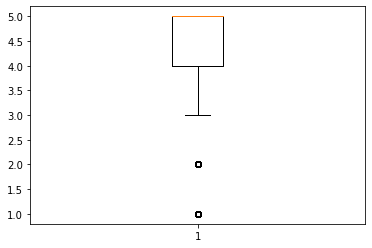

In [52]:
plt.boxplot(df_reviews['review_score'])

<AxesSubplot:xlabel='review_score', ylabel='Count'>

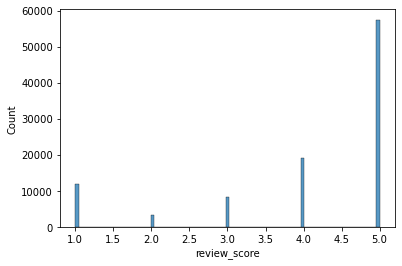

In [53]:
sns.histplot(df_reviews['review_score'])

<AxesSubplot:xlabel='review_score', ylabel='Count'>

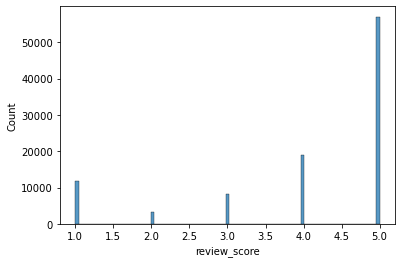

In [54]:
sns.histplot(df_reviews.groupby('order_id').mean()['review_score'])

In [55]:
df_reviews['review_score'].describe()

count    100000.000000
mean          4.070890
std           1.359663
min           1.000000
25%           4.000000
50%           5.000000
75%           5.000000
max           5.000000
Name: review_score, dtype: float64

### Joining dataset

In [56]:
master = master.join(df_reviews.groupby('order_id').mean(),on='order_id')

## Order items dataset

In [57]:
df_items = pd.read_csv('data/olist_order_items_dataset.csv')

In [58]:
df_items.describe()

,order_item_id,price,freight_value
count,112650.000000,112650.000000,112650.000000
mean,1.197834,120.653739,19.990320
std,0.705124,183.633928,15.806405
min,1.000000,0.850000,0.000000
25%,1.000000,39.900000,13.080000
50%,1.000000,74.990000,16.260000
75%,1.000000,134.900000,21.150000
max,21.000000,6735.000000,409.680000


In [59]:
df_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


{'whiskers': [<matplotlib.lines.Line2D at 0x200184e0f40>,
 'caps': [<matplotlib.lines.Line2D at 0x200184ef640>,
 'boxes': [<matplotlib.lines.Line2D at 0x200184e01f0>],
 'medians': [<matplotlib.lines.Line2D at 0x200184efcd0>],
 'fliers': [<matplotlib.lines.Line2D at 0x200184fa040>],
 'means': []}

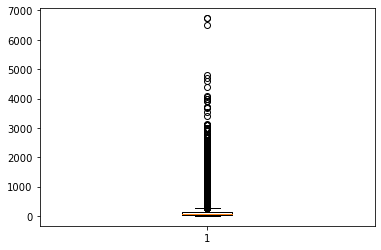

In [60]:
plt.boxplot(df_items['price'])

In [61]:
df_items['order_item_id'].value_counts()

1     98666
2      9803
3      2287
4       965
5       460
6       256
7        58
8        36
9        28
10       25
11       17
12       13
13        8
14        7
15        5
20        3
16        3
17        3
18        3
19        3
21        1
Name: order_item_id, dtype: int64

In [62]:
master.to_pickle('data/master')

In [63]:
master = pd.read_pickle('data/master')

## Building final dataset

In [65]:
df_customer_unique = pd.DataFrame(df_customers['customer_unique_id'].unique(),columns=['customer_unique_id'])

In [66]:
def create_master_quarter(master,Q_begin,Q_end):
    '''Returns merged dataframe corresponding to the period between the two specified quarter included. Q must be string 2017Q1'''
    Q_begin = pd.Period(Q_begin)
    Q_end = pd.Period(Q_end)
    df = master[((Q_begin <= master['quarter']) & (master['quarter'] <= Q_end))]
    return df

### Features

In [67]:
def compute_features(master, customer):

    # Frequency
    df = customer.join(master.groupby('customer_unique_id').count()['order_id'],
                       on='customer_unique_id',
                       how='inner')
    df.rename(columns={'order_id': 'frequency'}, inplace=True)

    # recency
    df = df.join(master[['recency', 'customer_unique_id']].groupby('customer_unique_id').min(),
                 on='customer_unique_id')
    df['recency'] = df['recency'] - df['recency'].min()
    
    # monetary
    df = df.join(master[['customer_unique_id', 'payment_value']].groupby('customer_unique_id').sum(),
                 on='customer_unique_id')
    df.rename(columns={'payment_value': 'monetary'}, inplace=True)
    
    #monetary_log
    df['monetary'] = df['monetary'].replace(0,1)
    df['monetary_log'] = np.log(df['monetary'])

    # review score count and mean
    df = df.join(master[['customer_unique_id', 'review_score']].groupby('customer_unique_id').count(),
                 on='customer_unique_id')
    df.rename(columns={'review_score': 'review_counts'}, inplace=True)

    df = df.join(master[['customer_unique_id', 'review_score']].groupby('customer_unique_id').mean(),
                 on='customer_unique_id')

    # delivery time
    df = df.join(master[['customer_unique_id', 'delivery_difference_time']].groupby('customer_unique_id').mean(),
                 on='customer_unique_id')
    
    # log delivery time
    df['delivery_difference_time'] = df['delivery_difference_time'].replace(0,1)
    
    pos_index = df[df['delivery_difference_time']>0].index
    neg_index = df[df['delivery_difference_time']<0].index
    
    df['delivery_difference_time_log'] = df['delivery_difference_time'] 

    df.loc[pos_index,'delivery_difference_time_log'] = np.log(df.loc[pos_index,'delivery_difference_time'])
    df.loc[neg_index,'delivery_difference_time_log'] = -np.log(np.abs(df.loc[neg_index,'delivery_difference_time']))
      
    
    # Mean installment
    df = df.join(master[['customer_unique_id', 'payment_installments']].groupby('customer_unique_id').mean(),
                 on='customer_unique_id')

    return df

In [113]:
def display_distribution(df,cols,title):
    size = len(cols)
    nb_row = size//3
    fig,axs = plt.subplots(nb_row,3,figsize=(12,12))
    i=0
    for col in cols:
        sns.boxplot(x = df[col],ax=axs[i//3,i%3])
        #axs[i//3,i%3].boxplot(df[col])
        axs[i//3,i%3].set_title(col)
        i+=1
    plt.suptitle(title)
    plt.tight_layout()
   
        

## Creating Quarterly datasets

In [69]:
master.groupby('quarter').count()

,order_id,payment_sequential,payment_type,payment_installments,payment_value,total_order_payment_amount,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,...,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,purchase_weekday,purchase_period,delivery_difference_time,recency,review_score
quarter,,,,,,,,,,,,,,,,,,,,,
2016Q3,4,3,3,3,3,3,4,4,4,4,...,4,4,2,1,4,4,4,1,4,4
2016Q4,343,343,343,343,343,343,343,343,343,343,...,343,337,297,288,343,343,343,288,343,343
2017Q1,5573,5573,5573,5573,5573,5573,5573,5573,5573,5573,...,5573,5554,5333,5248,5573,5573,5573,5248,5573,5573
2017Q2,9951,9951,9951,9951,9951,9951,9951,9951,9951,9951,...,9951,9931,9728,9545,9951,9951,9951,9545,9951,9951
2017Q3,13383,13383,13383,13383,13383,13383,13383,13383,13383,13383,...,13383,13363,13049,12911,13383,13383,13383,12911,13383,13383
2017Q4,18618,18618,18618,18618,18618,18618,18618,18618,18618,18618,...,18618,18597,18187,18019,18618,18618,18618,18019,18618,18618
2018Q1,22027,22027,22027,22027,22027,22027,22027,22027,22027,22027,...,22027,22019,21770,21425,22027,22027,22027,21425,22027,22027
2018Q2,20763,20763,20763,20763,20763,20763,20763,20763,20763,20763,...,20763,20755,20617,20416,20763,20763,20763,20416,20763,20763
2018Q3,13221,13221,13221,13221,13221,13221,13221,13221,13221,13221,...,13221,13152,13016,12902,13221,13221,13221,12902,13221,13221


In [70]:
quarters = master.groupby('quarter').count().index[3:-1]

In [153]:
quarters_df=[]

In [154]:
for i in range(len(quarters)):
    quarters_df.append(
        compute_features(create_master_quarter(master,quarters[i],quarters[i])
                         ,df_customer_unique)
    )
   

In [115]:
full_df = compute_features(create_master_quarter(master,quarters[0],quarters[-1])
                         ,df_customer_unique)

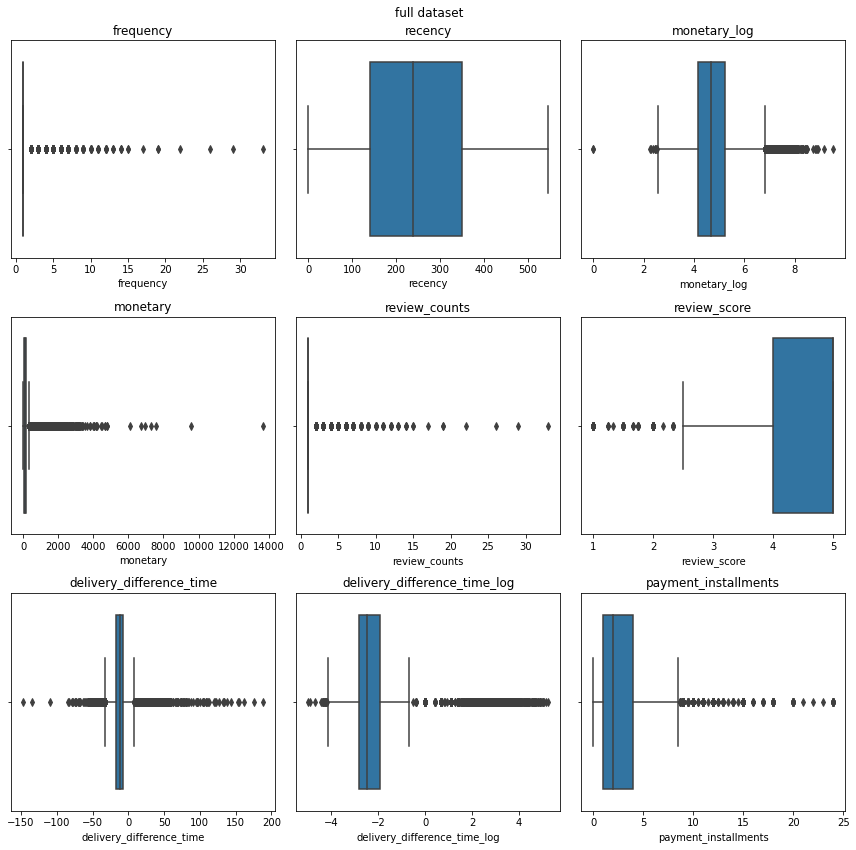

In [74]:
display_distribution(full_df,['frequency', 'recency', 'monetary_log','monetary', 'review_counts', 'review_score',
       'delivery_difference_time', 'delivery_difference_time_log','payment_installments'],'full dataset')

## Quantile transformer

In [157]:
def compute_QT_features(df,columns):
    QT = QuantileTransformer()
    QT_df=pd.DataFrame(index = df.index)
    for col in cols:
        QT_df[col] = QT.fit_transform(np.array(df[col].values).reshape(-1,1))
    df = df.join(QT_df,lsuffix='',rsuffix='_QT')
        
    return df

In [116]:
full_df.columns

Index(['customer_unique_id', 'frequency', 'recency', 'monetary',
       'monetary_log', 'review_counts', 'review_score',
       'delivery_difference_time', 'delivery_difference_time_log',
       'payment_installments'],
      dtype='object')

In [ ]:
cols = ['frequency', 'recency', 'monetary_log','monetary', 'review_counts', 'review_score',
       'delivery_difference_time', 'delivery_difference_time_log','payment_installments']

In [119]:
full_df = compute_QT_features(full_df,cols)

In [158]:
for i in range(len(quarters)):
    quarters_df[i] = compute_QT_features(quarters_df[i],cols)
    
   

In [120]:
full_df

,customer_unique_id,frequency,recency,monetary,monetary_log,review_counts,review_score,delivery_difference_time,delivery_difference_time_log,payment_installments,frequency_QT,recency_QT,monetary_log_QT,monetary_QT,review_counts_QT,review_score_QT,delivery_difference_time_QT,delivery_difference_time_log_QT,payment_installments_QT
0,861eff4711a542e4b93843c6dd7febb0,1,501.0,146.87,4.989548,1,4.0,-11.0,-2.397895,2.0,0.0,0.956456,0.649541,0.649541,0.0,0.33033,0.556056,0.556056,0.549049
1,290c77bc529b7ac935b93aa66c333dc3,1,259.0,335.48,5.815562,1,5.0,-8.0,-2.079442,8.0,0.0,0.551552,0.908653,0.908652,0.0,1.00000,0.704705,0.704705,0.919920
2,060e732b5b29e8181a18229c7b0b2b5e,1,133.0,157.73,5.060885,1,5.0,1.0,0.000000,7.0,0.0,0.225726,0.683172,0.683172,0.0,1.00000,0.928428,0.920420,0.890390
3,259dac757896d24d7702b9acbbff3f3c,1,200.0,173.30,5.155024,1,5.0,-13.0,-2.564949,1.0,0.0,0.401401,0.727803,0.727803,0.0,1.00000,0.451451,0.421421,0.241742
4,345ecd01c38d18a9036ed96c73b8d066,1,62.0,252.25,5.530421,1,5.0,-6.0,-1.791759,8.0,0.0,0.079580,0.854813,0.854813,0.0,1.00000,0.801802,0.801802,0.919920
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96091,1a29b476fee25c95fbafc67c5ac95cf8,1,175.0,88.78,4.486161,1,4.0,-12.0,-2.484907,6.0,0.0,0.339339,0.407630,0.407630,0.0,0.33033,0.507007,0.483984,0.863363
96092,d52a67c98be1cf6a5c84435bd38d095d,1,178.0,129.06,4.860277,1,5.0,-9.0,-2.197225,3.0,0.0,0.346847,0.586973,0.586973,0.0,1.00000,0.654154,0.654154,0.665666
96093,e9f50caf99f032f0bf3c55141f019d99,1,173.0,56.04,4.026066,1,1.0,7.0,1.945910,5.0,0.0,0.335335,0.202243,0.202243,0.0,0.00000,0.967968,0.965966,0.815816
96094,73c2643a0a458b49f58cea58833b192e,1,329.0,711.07,6.566771,1,5.0,-19.0,-2.944439,2.0,0.0,0.717718,0.975189,0.975187,0.0,1.00000,0.169169,0.169169,0.549049


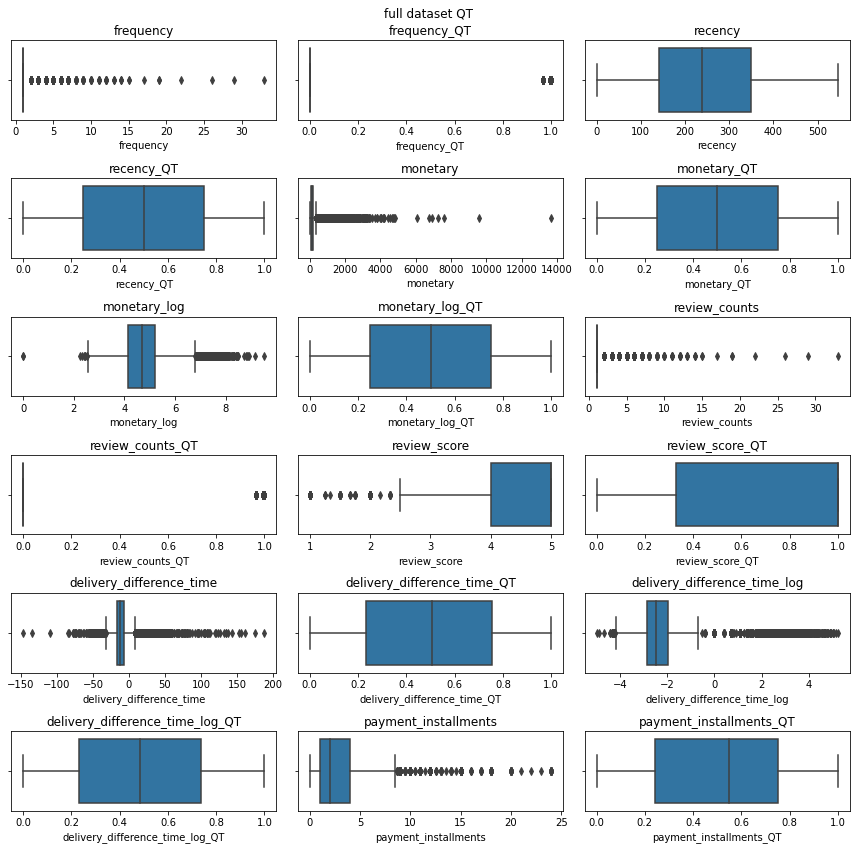

In [121]:
display_distribution(full_df,['frequency',
                              'frequency_QT',
                              'recency',
                              'recency_QT',
                              'monetary',
                              'monetary_QT',
                              'monetary_log',
                              'monetary_log_QT',                              
                              'review_counts',
                              'review_counts_QT',                                                          
                              'review_score',
                              'review_score_QT',
                              'delivery_difference_time',
                              'delivery_difference_time_QT',
                              'delivery_difference_time_log',
                              'delivery_difference_time_log_QT',
                              'payment_installments',
                             'payment_installments_QT']
                     ,'full dataset QT')

## Missing values

In [175]:
quarters_df[3].isna().sum()

customer_unique_id                 0
frequency                          0
recency                            0
monetary                           0
monetary_log                       0
review_counts                      0
review_score                       0
delivery_difference_time           0
delivery_difference_time_log       0
payment_installments               0
frequency_QT                       0
recency_QT                         0
monetary_log_QT                    0
monetary_QT                        0
review_counts_QT                   0
review_score_QT                    0
delivery_difference_time_QT        0
delivery_difference_time_log_QT    0
payment_installments_QT            0
dtype: int64

In [163]:
 imputer = SimpleImputer(strategy='mean')

In [165]:
full_df['delivery_difference_time'] = imputer.fit_transform(
                                      np.array(full_df['delivery_difference_time'].values).reshape(-1, 1))

In [168]:
def imputer(df,cols):
    imputer = SimpleImputer(strategy='mean')
    for col in cols:
        df[col] = imputer.fit_transform(np.array(df[col].values.reshape(-1,1)))
    return df

In [169]:
full_df = imputer(full_df,['delivery_difference_time','delivery_difference_time_log',
                          'delivery_difference_time_QT','delivery_difference_time_log_QT'])

In [170]:
for i in range(len(quarters)):
    quarters_df[i] = imputer(quarters_df[i],['delivery_difference_time','delivery_difference_time_log',
                          'delivery_difference_time_QT','delivery_difference_time_log_QT'])

In [176]:
np.save('data/quarters_df',quarters_df,allow_pickle=True)

C:\Users\Soyann\Code\Install\anaconda3\lib\site-packages\numpy\core\_asarray.py:136: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray
  return array(a, dtype, copy=False, order=order, subok=True)


In [177]:
full_df.to_pickle('data/full_df')

## PCA

In [140]:
full_df.columns

Index(['customer_unique_id', 'frequency', 'recency', 'monetary',
       'monetary_log', 'review_counts', 'review_score',
       'delivery_difference_time', 'delivery_difference_time_log',
       'payment_installments', 'frequency_QT', 'recency_QT', 'monetary_log_QT',
       'monetary_QT', 'review_counts_QT', 'review_score_QT',
       'delivery_difference_time_QT', 'delivery_difference_time_log_QT',
       'payment_installments_QT'],
      dtype='object')

In [141]:
X = full_df.drop(columns=['customer_unique_id', 'frequency', 'recency', 'monetary',
       'monetary_log', 'review_counts', 'review_score',
       'delivery_difference_time', 'delivery_difference_time_log',
       'payment_installments','monetary_log_QT','delivery_difference_time_log_QT'])

In [142]:
features = X.columns

In [143]:
features

Index(['frequency_QT', 'recency_QT', 'monetary_QT', 'review_counts_QT',
       'review_score_QT', 'delivery_difference_time_QT',
       'payment_installments_QT'],
      dtype='object')

In [144]:
imputer = SimpleImputer(strategy="mean")

In [145]:
X_impute = imputer.fit_transform(X)

In [146]:
pca = PCA()

In [147]:
pca.fit(X_impute)

PCA()

In [148]:
pca.explained_variance_ratio_.cumsum()

array([0.28872803, 0.48299792, 0.65420736, 0.79905428, 0.92190546,
       1.        , 1.        ])

In [149]:
def display_circles(pcs, n_comp, pca, axis_ranks, labels=None, label_rotation=0, lims=None):
    for d1, d2 in axis_ranks:  # On affiche les 3 premiers plans factoriels, donc les 6 premières composantes
        if d2 < n_comp:

            # initialisation de la figure
            fig, ax = plt.subplots(figsize=(12, 12))

            # détermination des limites du graphique
            if lims is not None:
                xmin, xmax, ymin, ymax = lims
            elif pcs.shape[1] < 30:
                xmin, xmax, ymin, ymax = -1, 1, -1, 1
            else:
                xmin, xmax, ymin, ymax = min(pcs[d1, :]), max(
                    pcs[d1, :]), min(pcs[d2, :]), max(pcs[d2, :])

            # affichage des flèches
            # s'il y a plus de 30 flèches, on n'affiche pas le triangle à leur extrémité
            if pcs.shape[1] < 30:
                plt.quiver(np.zeros(pcs.shape[1]), np.zeros(pcs.shape[1]),
                           pcs[d1, :], pcs[d2, :],
                           angles='xy', scale_units='xy', scale=1, color="grey")
                # (voir la doc : https://matplotlib.org/api/_as_gen/matplotlib.pyplot.quiver.html)
            else:
                lines = [[[0, 0], [x, y]] for x, y in pcs[[d1, d2]].T]
                ax.add_collection(LineCollection(
                    lines, axes=ax, alpha=.1, color='black'))

            # affichage des noms des variables
            if labels is not None:
                for i, (x, y) in enumerate(pcs[[d1, d2]].T):
                    if x >= xmin and x <= xmax and y >= ymin and y <= ymax:
                        plt.text(x, y, labels[i], fontsize='14', ha='center',
                                 va='center', rotation=label_rotation, color="blue", alpha=0.5)

            # affichage du cercle
            circle = plt.Circle((0, 0), 1, facecolor='none', edgecolor='b')
            plt.gca().add_artist(circle)

            # définition des limites du graphique
            plt.xlim(xmin, xmax)
            plt.ylim(ymin, ymax)

            # affichage des lignes horizontales et verticales
            plt.plot([-1, 1], [0, 0], color='grey', ls='--')
            plt.plot([0, 0], [-1, 1], color='grey', ls='--')

            # nom des axes, avec le pourcentage d'inertie expliqué
            plt.xlabel('F{} ({}%)'.format(
                d1+1, round(100*pca.explained_variance_ratio_[d1], 1)))
            plt.ylabel('F{} ({}%)'.format(
                d2+1, round(100*pca.explained_variance_ratio_[d2], 1)))

            plt.title("Cercle des corrélations (F{} et F{})".format(d1+1, d2+1))
            plt.show(block=False)

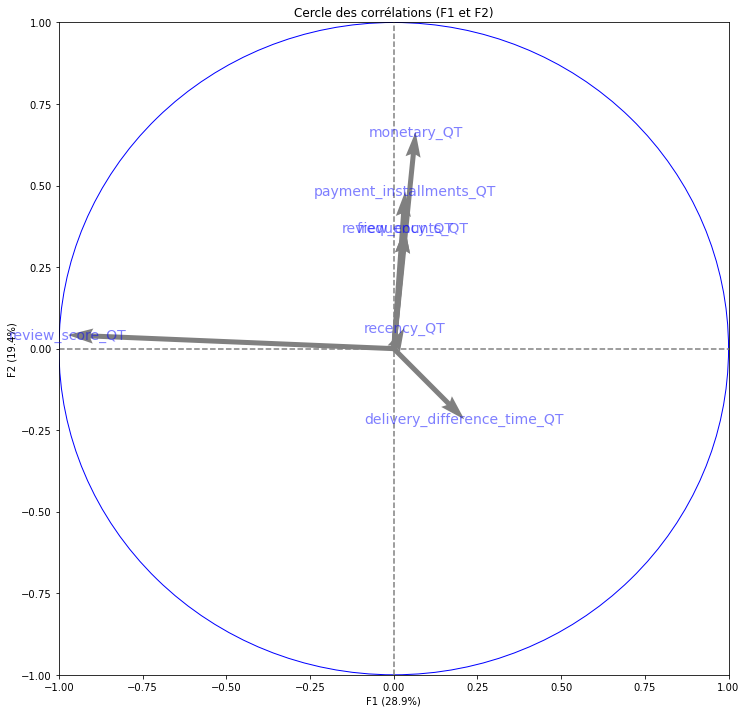

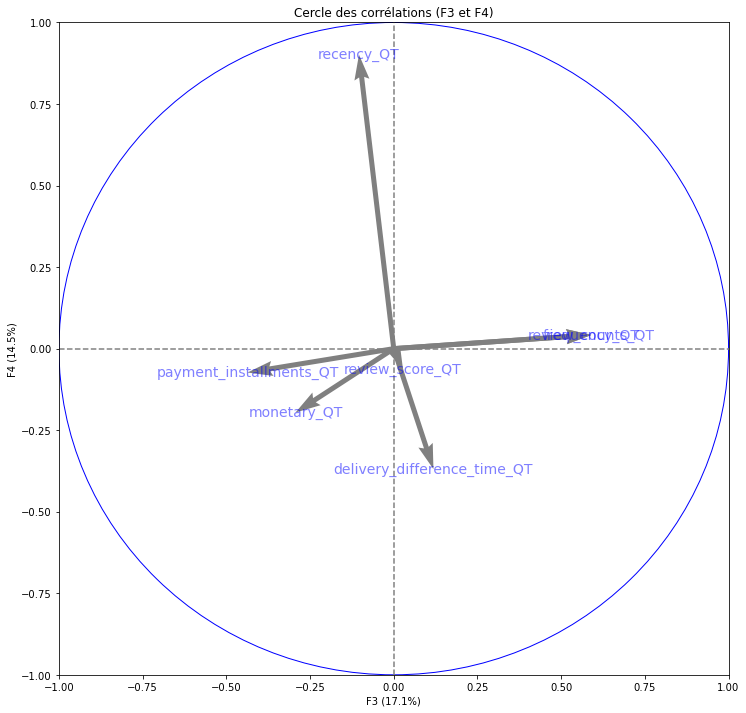

In [152]:
pcs = pca.components_
display_circles(pcs, 4, pca, [(0,1),(2,3),(4,5)], labels = np.array(features),label_rotation=0)